In [1]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])

import os, random, gc, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 55)
print("ENVIRONMENT REPORT")
print("=" * 55)
print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    free, total = torch.cuda.mem_get_info(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {total/1e9:.1f} GB total | {free/1e9:.2f} GB free")
print("Cell 1 complete ✓")


ENVIRONMENT REPORT
PyTorch : 2.9.0+cu126
timm    : 1.0.24
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB total | 15.53 GB free
Cell 1 complete ✓


In [3]:
# ── Cell 2: Config & Load CSVs ─────────────────────────────────────────────
BASE    = Path("/kaggle/input/datasets/omkarphadtare30/deepguard-dataset")
CSVDIR  = BASE / "csvs"
IMGROOT = BASE

CFG = dict(
    model_name       = "legacy_xception",
    num_classes      = 2,
    dropout          = 0.5,
    img_size         = 299,
    img_mean         = (0.5, 0.5, 0.5),
    img_std          = (0.5, 0.5, 0.5),
    num_workers      = 4,
    phase1_epochs    = 5,
    phase1_lr        = 1e-3,
    phase1_patience  = 3,
    phase1_batch     = 32,
    phase2_epochs    = 20,
    phase2_lr_bb     = 5e-6,
    phase2_lr_head   = 5e-5,
    phase2_patience  = 6,
    phase2_batch     = 32,
    accum_steps      = 2,
    weight_decay     = 2e-4,
    label_smoothing  = 0.05,
    grad_clip        = 1.0,
    mixup_alpha      = 0.2,
    cutmix_alpha     = 0.5,
    mix_prob         = 0.4,
    fake_weight_boost= 1.15,
    sched_patience   = 4,
    sched_factor     = 0.4,
    sched_min_lr     = 5e-8,
    model_path       = "/kaggle/working/best_xception_v3.pth",
    time_budget_sec  = 11 * 3600,
)

# ── Load CSVs ──────────────────────────────────────────────────────────────
train_df = pd.read_csv(CSVDIR / "fixed_train.csv")
val_df   = pd.read_csv(CSVDIR / "fixed_val.csv")
test_df  = pd.read_csv(CSVDIR / "fixed_test.csv")

# ── Auto-detect column names ───────────────────────────────────────────────
print("CSV Columns found:", list(train_df.columns))
PATH_COL  = train_df.columns[0]   # first column = path
LABEL_COL = "label"
print(f"Path column  → '{PATH_COL}'")
print(f"Label column → '{LABEL_COL}'")

print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"{'Split':8} {'Total':8} {'Real':8} {'Fake':8}")
print("-" * 36)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    r = (df[LABEL_COL] == 0).sum()
    f = (df[LABEL_COL] == 1).sum()
    print(f"{name:8} {len(df):8,} {r:8,} {f:8,}")

# ── Spot-check 10 paths ───────────────────────────────────────────────────
sample = train_df.sample(10, random_state=42)
broken = [row[PATH_COL] for _, row in sample.iterrows()
          if not os.path.exists(row[PATH_COL])]
print(f"\nPath check: {len(broken)} broken out of 10")
if broken:
    for b in broken: print(f"  BROKEN: {b}")
else:
    print("All 10 paths valid ✓")

# ── Class weights ─────────────────────────────────────────────────────────
counts = train_df[LABEL_COL].value_counts().sort_index().values
class_weights = torch.tensor([1.0 / c for c in counts], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 2
class_weights[1] *= CFG["fake_weight_boost"]
class_weights = class_weights / class_weights.sum() * 2
class_weights = class_weights.to(DEVICE)
print(f"\nClass weights  Real: {class_weights[0]:.4f}  Fake: {class_weights[1]:.4f}")
torch.backends.cudnn.benchmark = True
print("Cell 2 complete ✓")


CSV Columns found: ['imagepath', 'label', 'split']
Path column  → 'imagepath'
Label column → 'label'
DATASET SUMMARY
Split    Total    Real     Fake    
------------------------------------
train     239,828  119,914  119,914
val        32,374   16,187   16,187
test       15,982    7,991    7,991

Path check: 0 broken out of 10
All 10 paths valid ✓

Class weights  Real: 0.9302  Fake: 1.0698
Cell 2 complete ✓


In [4]:
# ── Cell 3: Transforms ────────────────────────────────────────────────────
S    = CFG["img_size"]     # 299
MEAN = CFG["img_mean"]
STD  = CFG["img_std"]

phase1_transform = T.Compose([
    T.Resize((S, S)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

phase2_transform = T.Compose([
    T.Resize((S + 24, S + 24)),
    T.RandomCrop(S),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.07),
    T.RandomRotation(degrees=12),
    T.RandomGrayscale(p=0.05),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.10)),
])

val_transform = T.Compose([
    T.Resize((S, S)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# ── Verification ──────────────────────────────────────────────────────────
print(f"Phase 1 steps : {len(phase1_transform.transforms)}")
print(f"Phase 2 steps : {len(phase2_transform.transforms)}")
print(f"Val/Test steps: {len(val_transform.transforms)}")
print("Cell 3 complete ✓")


Phase 1 steps : 4
Phase 2 steps : 11
Val/Test steps: 3
Cell 3 complete ✓


In [5]:
# ── Cell 4: Dataset & DataLoaders ─────────────────────────────────────────
class DeepfakeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row[LABEL_COL], dtype=torch.long)
        try:
            img = Image.open(row[PATH_COL]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (CFG["img_size"], CFG["img_size"]), 0)
        if self.transform:
            img = self.transform(img)
        return img, label

def make_loaders(train_transform):
    kw = dict(num_workers=CFG["num_workers"], pin_memory=True,
              prefetch_factor=2, persistent_workers=True)
    train_ds = DeepfakeDataset(train_df, train_transform)
    val_ds   = DeepfakeDataset(val_df,   val_transform)
    test_ds  = DeepfakeDataset(test_df,  val_transform)
    return (
        DataLoader(train_ds, batch_size=CFG["phase1_batch"], shuffle=True,
                   drop_last=True,  **kw),
        DataLoader(val_ds,   batch_size=CFG["phase1_batch"], shuffle=False,
                   drop_last=False, **kw),
        DataLoader(test_ds,  batch_size=CFG["phase1_batch"], shuffle=False,
                   drop_last=False, **kw),
    )

train_loader, val_loader, test_loader = make_loaders(phase1_transform)

print("=" * 55)
print("DATALOADER VERIFICATION")
print("=" * 55)
print(f"Train : {len(train_loader):,} batches | {len(train_loader.dataset):,} images")
print(f"Val   : {len(val_loader):,} batches | {len(val_loader.dataset):,} images")
print(f"Test  : {len(test_loader):,} batches | {len(test_loader.dataset):,} images")
print(f"Batch size    : {CFG['phase1_batch']}")
print(f"Eff. batch    : {CFG['phase1_batch'] * CFG['accum_steps']}")

imgs, labels = next(iter(train_loader))
print(f"\nBatch shape  : {tuple(imgs.shape)}")
print(f"Labels sample: {labels[:8].tolist()}")
print(f"Image dtype  : {imgs.dtype}")
print(f"Image minmax : {imgs.min():.3f} | {imgs.max():.3f}")

# Batch balance check
n_real = (labels == 0).sum().item()
n_fake = (labels == 1).sum().item()
print(f"Batch balance: {n_real} real | {n_fake} fake")
print("Cell 4 complete ✓")


DATALOADER VERIFICATION
Train : 7,494 batches | 239,828 images
Val   : 1,012 batches | 32,374 images
Test  : 500 batches | 15,982 images
Batch size    : 32
Eff. batch    : 64

Batch shape  : (32, 3, 299, 299)
Labels sample: [0, 1, 1, 0, 0, 0, 0, 1]
Image dtype  : torch.float32
Image minmax : -1.000 | 1.000
Batch balance: 18 real | 14 fake
Cell 4 complete ✓


In [6]:
# ── Cell 5: Model + Augmentation Functions ────────────────────────────────
class XceptionDeepfake(nn.Module):
    def __init__(self, model_name, dropout, num_classes):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=True, num_classes=0, drop_rate=dropout
        )
        feat_dim = self.backbone.num_features  # 2048 for legacy_xception
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
        print("Backbone FROZEN — training head only")

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
        print("Backbone UNFROZEN — full fine-tuning enabled")

# MixUp
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

# CutMix
def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cw, ch = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = np.clip(cx - cw//2, 0, W), np.clip(cx + cw//2, 0, W)
    y1, y2 = np.clip(cy - ch//2, 0, H), np.clip(cy + ch//2, 0, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=0.5):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    mixed = x.clone(); mixed[:, :, x1:x2, y1:y2] = x[idx, :, x1:x2, y1:y2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2))
    return mixed, y, y[idx], lam

def mixed_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

# Build model
model = XceptionDeepfake(
    model_name=CFG["model_name"],
    dropout=CFG["dropout"],
    num_classes=CFG["num_classes"]
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters()) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Total params     : {total:.2f}M")
print(f"Trainable params : {trainable:.2f}M")
print(f"Feature dim      : {model.backbone.num_features}")
print("Cell 5 complete ✓")


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Total params     : 21.86M
Trainable params : 21.86M
Feature dim      : 2048
Cell 5 complete ✓


In [7]:
# ── Cell 6: Training Loop ─────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer, scaler,
              is_train=True, use_mix=False, accum_steps=1):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []
    if is_train: optimizer.zero_grad()
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for i, (imgs, labels) in enumerate(tqdm(loader, desc="Train" if is_train else "Val", leave=False)):
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            mixed, lam, ya, yb = False, 1.0, labels, labels
            if is_train and use_mix and random.random() < CFG["mix_prob"]:
                if random.random() < 0.5:
                    imgs, ya, yb, lam = mixup_data(imgs, labels, CFG["mixup_alpha"])
                else:
                    imgs, ya, yb, lam = cutmix_data(imgs, labels, CFG["cutmix_alpha"])
                mixed = True
            with autocast("cuda"):
                logits = model(imgs)
                loss = mixed_criterion(criterion, logits, ya, yb, lam) if mixed else criterion(logits, labels)
                loss = loss / accum_steps
            if is_train:
                scaler.scale(loss).backward()
                if (i + 1) % accum_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                    scaler.step(optimizer); scaler.update()
                    optimizer.zero_grad()
            probs  = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            preds  = logits.argmax(dim=1).detach().cpu().numpy()
            labs   = labels.detach().cpu().numpy()
            total_loss += loss.item() * accum_steps * labels.size(0)
            correct    += (preds == labs).sum()
            total      += labels.size(0)
            all_probs.extend(probs); all_preds.extend(preds); all_labels.extend(labs)
    avg_loss = total_loss / total
    accuracy = correct / total
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, accuracy, auc, all_preds, all_labels

print("Training loop defined ✓")


Training loop defined ✓


In [8]:
#── Cell 7: Phase 1 — Head Only ───────────────────────────────────────────
TRAIN_START = time.time()

model.freeze_backbone()
optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["phase1_lr"], weight_decay=CFG["weight_decay"]
)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1, max_lr=CFG["phase1_lr"],
    steps_per_epoch=len(train_loader),
    epochs=CFG["phase1_epochs"], pct_start=0.3, anneal_strategy="cos"
)
criterion   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG["label_smoothing"])
scaler_p1   = GradScaler("cuda")
history_p1  = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_val_acc = 0.0
patience_ctr = 0

print("=" * 60)
print(f"PHASE 1 — Head Only | {CFG['phase1_epochs']} epochs max | patience {CFG['phase1_patience']}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.3f}M")
print("=" * 60)

for epoch in range(1, CFG["phase1_epochs"] + 1):
    # ⏱️ Time safety check
    elapsed = time.time() - TRAIN_START
    if elapsed > CFG["time_budget_sec"] * 0.3:   # use max 30% budget in phase1
        print(f"⏱️ Time budget threshold hit at Phase 1 epoch {epoch} — moving to Phase 2")
        break

    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p1, scaler_p1, is_train=True, use_mix=False
    )
    va_loss, va_acc, va_auc, _, _ = run_epoch(
        model, val_loader, criterion, optimizer_p1, scaler_p1, is_train=False
    )
    scheduler_p1.step()
    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_auc"],
                    [tr_loss, va_loss, tr_acc, va_acc, va_auc]):
        history_p1[k].append(v)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CFG["model_path"])
        saved = " ✅ saved"
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f"P1 Ep {epoch:02d}/{CFG['phase1_epochs']:02d} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f} AUC {va_auc:.4f}{saved}")

    if patience_ctr >= CFG["phase1_patience"]:
        print(f"Early stopping Phase 1 at epoch {epoch}")
        break

print(f"\nPhase 1 complete. Best Val Acc: {best_val_acc*100:.2f}%")
print("Cell 7 complete ✓")


Backbone FROZEN — training head only
PHASE 1 — Head Only | 5 epochs max | patience 3
Trainable params: 1.055M


P1 Ep 01/05 | Train Loss 0.5830 Acc 0.6958 | Val Loss 0.5384 Acc 0.7317 AUC 0.8191 ✅ saved


P1 Ep 02/05 | Train Loss 0.5494 Acc 0.7273 | Val Loss 0.5237 Acc 0.7450 AUC 0.8323 ✅ saved


P1 Ep 03/05 | Train Loss 0.5381 Acc 0.7379 | Val Loss 0.5140 Acc 0.7524 AUC 0.8401 ✅ saved


P1 Ep 04/05 | Train Loss 0.5297 Acc 0.7447 | Val Loss 0.5093 Acc 0.7588 AUC 0.8447 ✅ saved


P1 Ep 05/05 | Train Loss 0.5231 Acc 0.7499 | Val Loss 0.5054 Acc 0.7581 AUC 0.8487

Phase 1 complete. Best Val Acc: 75.88%
Cell 7 complete ✓


In [9]:
# ── Cell 8: Phase 2 — Full Fine-Tune 
model.load_state_dict(torch.load(CFG["model_path"], map_location=DEVICE, weights_only=True))
model.unfreeze_backbone()

# Rebuild loaders with strong augmentation
train_loader, val_loader, test_loader = make_loaders(phase2_transform)
# Update batch size for phase 2
train_loader = DataLoader(
    DeepfakeDataset(train_df, phase2_transform),
    batch_size=CFG["phase2_batch"], shuffle=True, drop_last=True,
    num_workers=CFG["num_workers"], pin_memory=True,
    prefetch_factor=2, persistent_workers=True
)

optimizer_p2 = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": CFG["phase2_lr_bb"]},
    {"params": model.head.parameters(),     "lr": CFG["phase2_lr_head"]},
], weight_decay=CFG["weight_decay"])

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode="max", factor=CFG["sched_factor"],
    patience=CFG["sched_patience"], min_lr=CFG["sched_min_lr"]
)
criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG["label_smoothing"])
scaler_p2  = GradScaler("cuda")
history_p2 = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_val_acc = 0.0
patience_ctr = 0

print("=" * 65)
print(f"PHASE 2 — Full Fine-Tune | {CFG['phase2_epochs']} epochs max | patience {CFG['phase2_patience']}")
print(f"Backbone LR: {CFG['phase2_lr_bb']}  |  Head LR: {CFG['phase2_lr_head']}")
print(f"Accum steps: {CFG['accum_steps']} (effective batch: {CFG['phase2_batch']*CFG['accum_steps']})")
print("=" * 65)

for epoch in range(1, CFG["phase2_epochs"] + 1):
    # ⏱️ Hard time-budget guard — stop before Kaggle kills session
    elapsed = time.time() - TRAIN_START
    remaining = CFG["time_budget_sec"] - elapsed
    print(f"  ⏱️  Elapsed: {elapsed/3600:.1f}h | Remaining budget: {remaining/3600:.1f}h")
    if remaining < 3600:   # less than 1 hour left → save & stop
        print("⚠️ Less than 1 hour remaining — stopping training to save model safely.")
        break

    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p2, scaler_p2,
        is_train=True, use_mix=True, accum_steps=CFG["accum_steps"]
    )
    va_loss, va_acc, va_auc, _, _ = run_epoch(
        model, val_loader, criterion, optimizer_p2, scaler_p2, is_train=False
    )
    scheduler_p2.step(va_acc)

    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_auc"],
                    [tr_loss, va_loss, tr_acc, va_acc, va_auc]):
        history_p2[k].append(v)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CFG["model_path"])
        saved = " ✅ saved"
        patience_ctr = 0
    else:
        patience_ctr += 1

    bb_lr = optimizer_p2.param_groups[0]["lr"]
    hd_lr = optimizer_p2.param_groups[1]["lr"]
    print(f"P2 Ep {epoch:02d}/{CFG['phase2_epochs']:02d} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {va_loss:.4f} Acc {va_acc:.4f} AUC {va_auc:.4f} | "
          f"LR bb {bb_lr:.2e} hd {hd_lr:.2e}{saved}")

    if patience_ctr >= CFG["phase2_patience"]:
        print(f"Early stopping Phase 2 at epoch {epoch}")
        break

print(f"\nPhase 2 complete. Best Val Acc: {best_val_acc*100:.2f}%")
print("Cell 8 complete ✓")


Backbone UNFROZEN — full fine-tuning enabled
PHASE 2 — Full Fine-Tune | 20 epochs max | patience 6
Backbone LR: 5e-06  |  Head LR: 5e-05
Accum steps: 2 (effective batch: 64)
  ⏱️  Elapsed: 1.7h | Remaining budget: 9.3h


P2 Ep 01/20 | Train Loss 0.5473 Acc 0.7119 | Val Loss 0.4416 Acc 0.8123 AUC 0.8958 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 2.7h | Remaining budget: 8.3h


P2 Ep 02/20 | Train Loss 0.4799 Acc 0.7592 | Val Loss 0.4123 Acc 0.8285 AUC 0.9167 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 3.6h | Remaining budget: 7.4h


P2 Ep 03/20 | Train Loss 0.4438 Acc 0.7827 | Val Loss 0.3821 Acc 0.8536 AUC 0.9374 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 4.5h | Remaining budget: 6.5h


P2 Ep 04/20 | Train Loss 0.4164 Acc 0.7995 | Val Loss 0.3495 Acc 0.8748 AUC 0.9481 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 5.5h | Remaining budget: 5.5h


P2 Ep 05/20 | Train Loss 0.3995 Acc 0.8097 | Val Loss 0.3235 Acc 0.8896 AUC 0.9577 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 6.4h | Remaining budget: 4.6h


P2 Ep 06/20 | Train Loss 0.3822 Acc 0.8211 | Val Loss 0.3310 Acc 0.8875 AUC 0.9611 | LR bb 5.00e-06 hd 5.00e-05
  ⏱️  Elapsed: 7.3h | Remaining budget: 3.7h


P2 Ep 07/20 | Train Loss 0.3712 Acc 0.8258 | Val Loss 0.3085 Acc 0.9000 AUC 0.9648 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 8.3h | Remaining budget: 2.7h


P2 Ep 08/20 | Train Loss 0.3590 Acc 0.8347 | Val Loss 0.2930 Acc 0.9085 AUC 0.9704 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 9.2h | Remaining budget: 1.8h


P2 Ep 09/20 | Train Loss 0.3476 Acc 0.8365 | Val Loss 0.2841 Acc 0.9126 AUC 0.9723 | LR bb 5.00e-06 hd 5.00e-05 ✅ saved
  ⏱️  Elapsed: 10.1h | Remaining budget: 0.9h
⚠️ Less than 1 hour remaining — stopping training to save model safely.

Phase 2 complete. Best Val Acc: 91.26%
Cell 8 complete ✓


Simple Test: 100%|██████████| 500/500 [01:11<00:00,  6.96it/s]


SIMPLE TEST RESULTS — XceptionNet v3 (No TTA)
Test Accuracy : 91.77%
Test AUC-ROC  : 0.9776
              precision    recall  f1-score   support

        Real     0.9004    0.9392    0.9194      7991
        Fake     0.9364    0.8961    0.9158      7991

    accuracy                         0.9177     15982
   macro avg     0.9184    0.9177    0.9176     15982
weighted avg     0.9184    0.9177    0.9176     15982



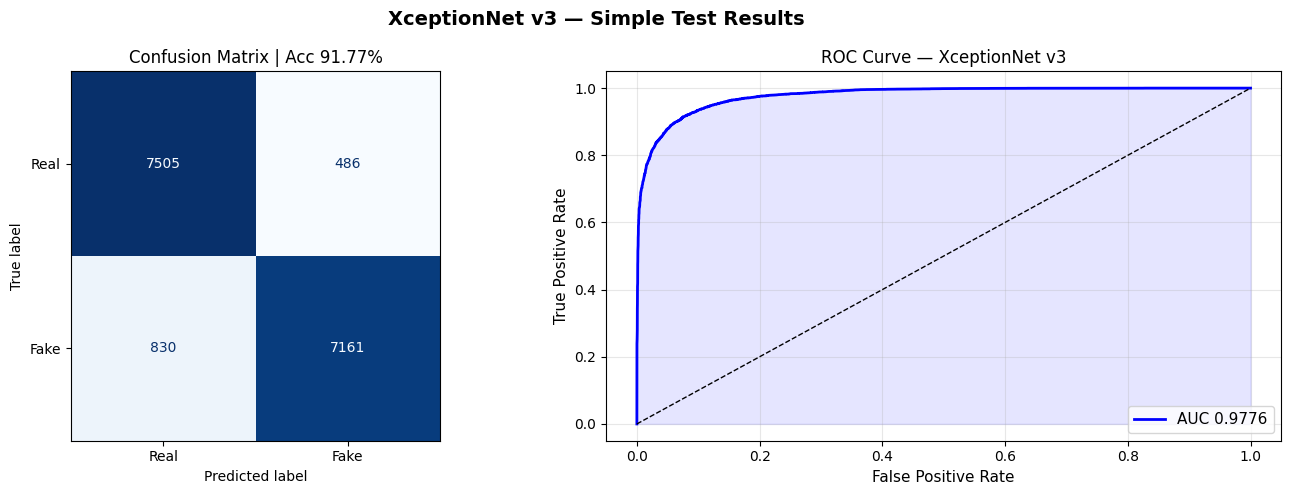

Saved: xception_v3_simple_test.png
Cell 9 complete ✓


In [10]:
# ── Cell 9: Simple Test (No TTA) + Plots ──────────────────────────────────
model.load_state_dict(torch.load(CFG["model_path"], map_location=DEVICE, weights_only=True))
model.eval()

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Simple Test"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast("cuda"):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
test_auc = roc_auc_score(all_labels, all_probs)

print("=" * 60)
print("SIMPLE TEST RESULTS — XceptionNet v3 (No TTA)")
print("=" * 60)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test AUC-ROC  : {test_auc:.4f}")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=["Real", "Fake"], digits=4))

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("XceptionNet v3 — Simple Test Results", fontsize=14, fontweight="bold")

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix | Acc {test_acc*100:.2f}%", fontsize=12)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC {test_auc:.4f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color="blue")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title("ROC Curve — XceptionNet v3", fontsize=12)
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/xception_v3_simple_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xception_v3_simple_test.png")
print("Cell 9 complete ✓")


In [11]:
# ── Cell 10: Define TTA Transforms + Function ─────────────────────────────
TTA_TRANSFORMS = [
    T.Compose([T.Resize((S, S)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S, S)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S+24, S+24)), T.CenterCrop(S), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S, S)), T.ColorJitter(brightness=0.15, contrast=0.15), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((S, S)), T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)), T.ToTensor(), T.Normalize(MEAN, STD)]),
]

def tta_predict(model, df, tta_transforms):
    model.eval()
    all_avg_probs = None
    all_labels    = None
    for t_idx, transform in enumerate(tta_transforms):
        ds     = DeepfakeDataset(df, transform)
        loader = DataLoader(ds, batch_size=CFG["phase1_batch"], shuffle=False,
                            num_workers=CFG["num_workers"], pin_memory=True,
                            persistent_workers=True)
        probs_list, labels_list = [], []
        with torch.no_grad():
            for imgs, labels in tqdm(loader, desc=f"TTA {t_idx+1}/{len(tta_transforms)}", leave=False):
                imgs = imgs.to(DEVICE, non_blocking=True)
                with autocast("cuda"):
                    logits = model(imgs)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                probs_list.append(probs)
                if t_idx == 0:
                    labels_list.extend(labels.numpy())
        probs_arr = np.concatenate(probs_list, axis=0)
        if all_avg_probs is None:
            all_avg_probs = probs_arr
            all_labels    = np.array(labels_list)
        else:
            all_avg_probs += probs_arr
    all_avg_probs /= len(tta_transforms)
    return np.argmax(all_avg_probs, axis=1), all_labels, all_avg_probs[:, 1]

print(f"TTA transforms : {len(TTA_TRANSFORMS)} views")
print("TTA function ready ✓")
print("Cell 10 complete ✓")


TTA transforms : 5 views
TTA function ready ✓
Cell 10 complete ✓


Running TTA on Validation set for threshold tuning...


Optimal threshold : 0.48  (both recalls ≥ 84%)
Best Val F1 macro : 0.9207

Running TTA on Test set...



FINAL TTA TEST RESULTS — XceptionNet v3
Threshold   : 0.48
Accuracy    : 92.35%
AUC-ROC     : 0.9804
Real Recall : 92.77%
Fake Recall : 91.93%
              precision    recall  f1-score   support

        Real     0.9200    0.9277    0.9238      7991
        Fake     0.9271    0.9193    0.9232      7991

    accuracy                         0.9235     15982
   macro avg     0.9235    0.9235    0.9235     15982
weighted avg     0.9235    0.9235    0.9235     15982



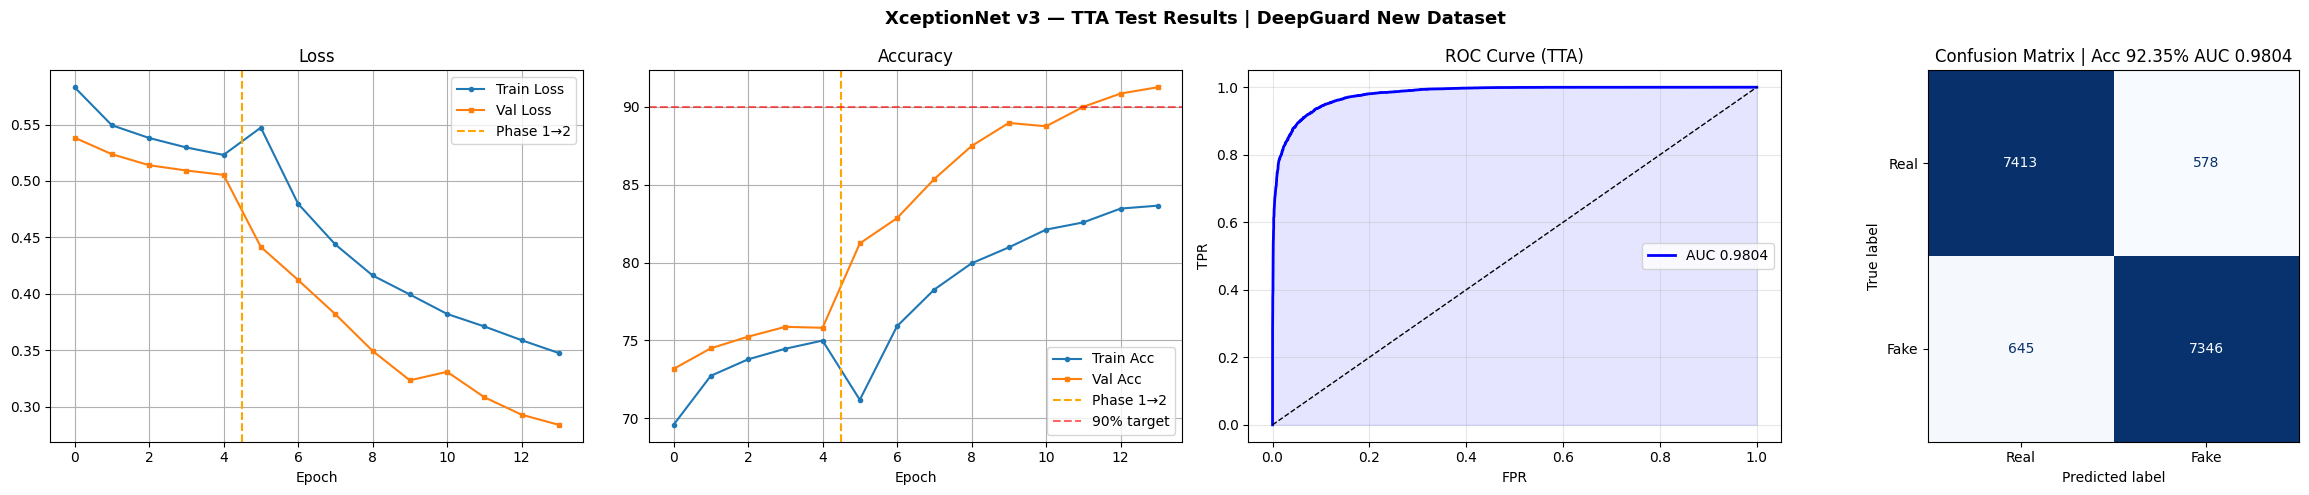


Saved: xception_v3_tta_results.png & xception_v3_predictions.csv
Total training time: 10.43 hours
Cell 11 complete ✓


In [12]:
# ── Cell 11: TTA Test + Threshold Tuning + Final Plots ────────────────────

# Threshold tuning on val set
print("Running TTA on Validation set for threshold tuning...")
val_preds_tta, val_labels_tta, val_probs_tta = tta_predict(model, val_df, TTA_TRANSFORMS)

best_thresh, best_f1 = 0.5, 0.0
for thresh in np.arange(0.30, 0.71, 0.01):
    preds_t   = (val_probs_tta >= thresh).astype(int)
    real_rec  = (preds_t[val_labels_tta == 0] == 0).mean()
    fake_rec  = (preds_t[val_labels_tta == 1] == 1).mean()
    if real_rec >= 0.84 and fake_rec >= 0.84:
        f1_t = f1_score(val_labels_tta, preds_t, average="macro")
        if f1_t > best_f1:
            best_f1 = f1_t; best_thresh = thresh

print(f"Optimal threshold : {best_thresh:.2f}  (both recalls ≥ 84%)")
print(f"Best Val F1 macro : {best_f1:.4f}")

# TTA on test set
print("\nRunning TTA on Test set...")
test_preds_tta, test_labels_tta, test_probs_tta = tta_predict(model, test_df, TTA_TRANSFORMS)
test_preds_tuned = (test_probs_tta >= best_thresh).astype(int)
test_acc_tta = (test_preds_tuned == test_labels_tta).mean()
test_auc_tta = roc_auc_score(test_labels_tta, test_probs_tta)
real_recall  = (test_preds_tuned[test_labels_tta == 0] == 0).mean()
fake_recall  = (test_preds_tuned[test_labels_tta == 1] == 1).mean()

print("\n" + "=" * 65)
print("FINAL TTA TEST RESULTS — XceptionNet v3")
print("=" * 65)
print(f"Threshold   : {best_thresh:.2f}")
print(f"Accuracy    : {test_acc_tta*100:.2f}%")
print(f"AUC-ROC     : {test_auc_tta:.4f}")
print(f"Real Recall : {real_recall*100:.2f}%")
print(f"Fake Recall : {fake_recall*100:.2f}%")
print("=" * 65)
print(classification_report(test_labels_tta, test_preds_tuned,
                             target_names=["Real", "Fake"], digits=4))

# ── Full training history plots + TTA results ──────────────────────────────
full_train_loss = history_p1["train_loss"] + history_p2["train_loss"]
full_val_loss   = history_p1["val_loss"]   + history_p2["val_loss"]
full_train_acc  = history_p1["train_acc"]  + history_p2["train_acc"]
full_val_acc    = history_p1["val_acc"]    + history_p2["val_acc"]
p1_end          = len(history_p1["train_loss"])

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("XceptionNet v3 — TTA Test Results | DeepGuard New Dataset",
             fontsize=13, fontweight="bold")

axes[0].plot(full_train_loss, label="Train Loss", marker="o", ms=3)
axes[0].plot(full_val_loss,   label="Val Loss",   marker="s", ms=3)
axes[0].axvline(p1_end - 0.5, color="orange", linestyle="--", label="Phase 1→2")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot([a*100 for a in full_train_acc], label="Train Acc", marker="o", ms=3)
axes[1].plot([a*100 for a in full_val_acc],   label="Val Acc",   marker="s", ms=3)
axes[1].axvline(p1_end - 0.5, color="orange", linestyle="--", label="Phase 1→2")
axes[1].axhline(y=90, color="red", linestyle="--", alpha=0.6, label="90% target")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

fpr, tpr, _ = roc_curve(test_labels_tta, test_probs_tta)
axes[2].plot(fpr, tpr, "b-", lw=2, label=f"AUC {test_auc_tta:.4f}")
axes[2].plot([0,1],[0,1],"k--", lw=1)
axes[2].fill_between(fpr, tpr, alpha=0.1, color="blue")
axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR")
axes[2].set_title("ROC Curve (TTA)"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

cm = confusion_matrix(test_labels_tta, test_preds_tuned)
ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"]).plot(
    ax=axes[3], colorbar=False, cmap="Blues"
)
axes[3].set_title(f"Confusion Matrix | Acc {test_acc_tta*100:.2f}% AUC {test_auc_tta:.4f}")

plt.tight_layout()
plt.savefig("/kaggle/working/xception_v3_tta_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Save predictions
pd.DataFrame({
    "label":    test_labels_tta,
    "pred":     test_preds_tuned,
    "prob_fake": test_probs_tta
}).to_csv("/kaggle/working/xception_v3_predictions.csv", index=False)

total_time = time.time() - TRAIN_START
print(f"\nSaved: xception_v3_tta_results.png & xception_v3_predictions.csv")
print(f"Total training time: {total_time/3600:.2f} hours")
print("Cell 11 complete ✓")
